In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
df = pd.read_csv("train.csv.zip")
df_test = pd.read_csv("test.csv.zip")

In [ ]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_test.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.shape

(42000, 785)

In [ ]:
df.columns

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=785)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [ ]:
df.isnull().sum()

,0
label,0
pixel0,0
pixel1,0
pixel2,0
pixel3,0
...,...
pixel779,0
pixel780,0
pixel781,0
pixel782,0


In [ ]:
df['label'].value_counts()

,count
label,
1,4684
7,4401
3,4351
9,4188
2,4177
6,4137
0,4132
4,4072
8,4063


In [ ]:
X_train = df.drop("label",axis=1).values
y_train = df["label"].values
X_test = df_test.values
# y_test is not available in df_test, it's the data we want to predict.

In [ ]:
X_train=X_train.astype('float32')/255.0
X_test=X_test.astype('float32')/255.0


In [ ]:
#reshapping
X_train_img=X_train.reshape(-1,28,28,)
X_test_img=X_test.reshape(-1,28,28)

In [ ]:
y_train_img=to_categorical(y_train,10)

In [ ]:
perceptron=Sequential(
    [
        Flatten(input_shape=(28,28)),
        Dense(10,activation='softmax'),

    ]
)

In [ ]:
perceptron.compile(optimizer='sgd',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history_perceptron=perceptron.fit(X_train_img,y_train_img,epochs=10,
                                  batch_size=32,validation_data=(X_train_img,y_train_img),verbose=1)


Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8032 - loss: 0.8596 - val_accuracy: 0.8659 - val_loss: 0.5516
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8745 - loss: 0.4934 - val_accuracy: 0.8834 - val_loss: 0.4506
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8865 - loss: 0.4289 - val_accuracy: 0.8910 - val_loss: 0.4087
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8925 - loss: 0.3970 - val_accuracy: 0.8950 - val_loss: 0.3844
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8968 - loss: 0.3770 - val_accuracy: 0.8993 - val_loss: 0.3677
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9003 - loss: 0.3628 - val_accuracy: 0.9020 - val_loss: 0.3556
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9029 - loss: 0.3521 - val_accuracy: 0.9049 - val_loss: 0.3465
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9051 - loss: 0.3436 - 

In [ ]:
accuracy_percp=perceptron.evaluate(X_train_img,y_train_img)[1]
accuracy_percp

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9088 - loss: 0.3274


0.9088333249092102

In [ ]:
#ANN
ann=Sequential(
    [
        Flatten(input_shape=(28,28)),
        Dense(128,activation='relu'),
        Dense(64,activation='relu'),
        Dense(10,activation='softmax'),

    ]
)

In [ ]:
ann.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history_ann=ann.fit(X_train_img,y_train_img,epochs=10,
                                  batch_size=32,validation_data=(X_train_img,y_train_img),verbose=1)

Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9200 - loss: 0.2754 - val_accuracy: 0.9632 - val_loss: 0.1265
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9643 - loss: 0.1159 - val_accuracy: 0.9762 - val_loss: 0.0780
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9750 - loss: 0.0805 - val_accuracy: 0.9841 - val_loss: 0.0518
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9818 - loss: 0.0582 - val_accuracy: 0.9878 - val_loss: 0.0397
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9849 - loss: 0.0469 - val_accuracy: 0.9883 - val_loss: 0.0354
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9881 - loss: 0.0353 - val_accuracy: 0.9921 - val_loss: 0.0252
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9909 - loss: 0.0284 - val_accuracy: 0.9951 - val_loss: 0.0165
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.9915 - loss: 0.02

In [ ]:
acc_ann=ann.evaluate(X_train_img,y_train_img)[1]
acc_ann

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9915 - loss: 0.0230


0.9914523959159851

In [ ]:
X_train_cnn=X_train.reshape(-1,28,28,1)
X_test_cnn=X_test.reshape(-1,28,28,1)

In [ ]:
cnn=Sequential(
    [
        Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
        MaxPooling2D((2,2)),
        Conv2D(64,(3,3),activation='relu'),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(128,activation='relu'),
        Dropout(0.5),
        Dense(10,activation='softmax'),

    ]
)

In [ ]:
cnn.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history_cnn=cnn.fit(X_train_cnn,y_train_img,epochs=5,
                                  batch_size=32,validation_data=(X_train_cnn,y_train_img),verbose=1)

Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 47s 36ms/step - accuracy: 0.9721 - loss: 0.0977 - val_accuracy: 0.9888 - val_loss: 0.0346
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 92s 43ms/step - accuracy: 0.9785 - loss: 0.0712 - val_accuracy: 0.9924 - val_loss: 0.0243
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 35ms/step - accuracy: 0.9834 - loss: 0.0552 - val_accuracy: 0.9942 - val_loss: 0.0185
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 48s 36ms/step - accuracy: 0.9856 - loss: 0.0442 - val_accuracy: 0.9949 - val_loss: 0.0165
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 91s 43ms/step - accuracy: 0.9868 - loss: 0.0410 - val_accuracy: 0.9949 - val_loss: 0.0159


In [ ]:
acc_cnn = cnn.evaluate(X_train_cnn, y_train_img)[1]
print(f"CNN Accuracy: {acc_cnn:.4f}")

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9949 - loss: 0.0159
CNN Accuracy: 0.9949


### Model Comparison: Accuracy

In [ ]:
model_accuracies = {
    'Model': ['Perceptron', 'ANN', 'CNN'],
    'Accuracy': [accuracy_percp, acc_ann, acc_cnn]
}

comparison_df = pd.DataFrame(model_accuracies)
display(comparison_df)

,Model,Accuracy
0,Perceptron,0.908833
1,ANN,0.991452
2,CNN,0.994881


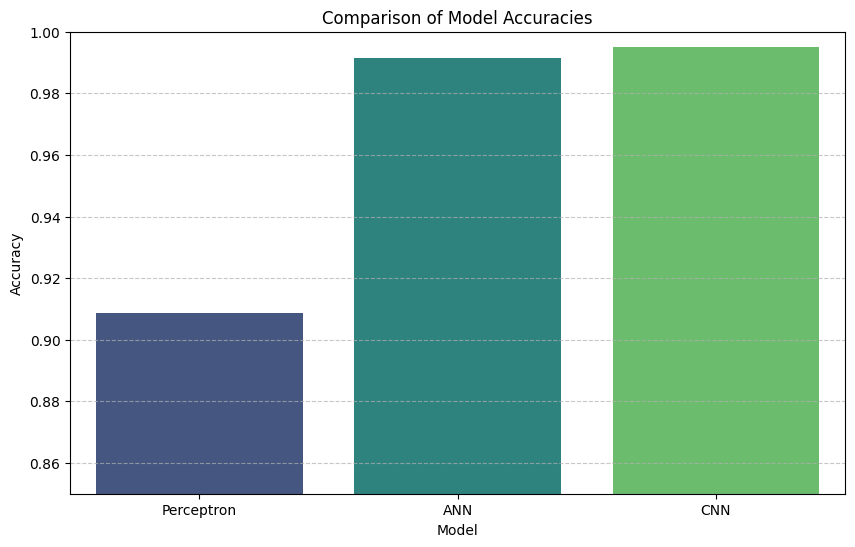

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette='viridis')
plt.title('Comparison of Model Accuracies')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.85, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


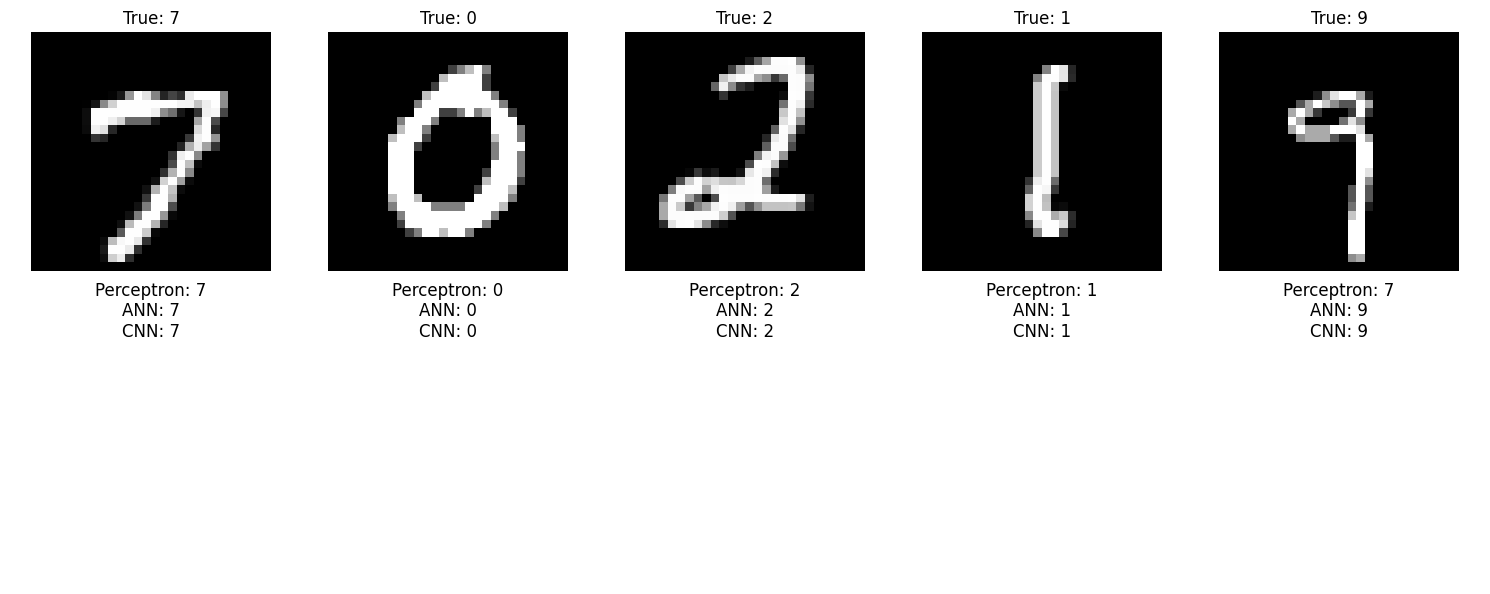

In [ ]:
show_side_by_side([perceptron, ann, cnn], ["Perceptron", "ANN", "CNN"], X_train_img, X_train_cnn, y_train, 5)